In [1]:
using QuadGK,LaTeXStrings,LinearAlgebra,BenchmarkTools;
using Plots;
using Interpolations;
using DataFrames,CSV;
import NLsolve,Roots;

In [2]:
# pyplot(frame=:box,size=(500,350));
gr(frame=:box, minorticks=5, size=(500,350),titlefontsize=11
    ,guidefontsize=12,tickfontsize=11,legendfontsize=9,
    bg_color_legend = RGBA(1,1,1,0.15), markerstrokecolor= :auto);

In [3]:
include("./libs/constants.jl");
include("./libs/pwa.jl");
include("./libs/potentials.jl");

In [4]:
λf(x, y, z) = x^2 + y^2 + z^2 - 2 * x * y - 2 * x * z - 2 * y * z
q0f(E, m1, m2, m3, m4) = abs(m3^2 - m4^2 - m1^2 + m2^2) / (2 * E)
μf(m1, m2) = m1 * m2 / (m1 + m2)

# redefine sqrt so that its cut is along the positive x axis
function xsqrt(x)
    imag(x) >=0 ? sqrt(x+0im) : -sqrt(x-0im)
end

xsqrt (generic function with 1 method)

# VGT

In [5]:
qon(E)=xsqrt(2*μf(mDsc,mDsn)*(E-mDsc-mDsn))

qon (generic function with 1 method)

In [6]:
qon(mDsc+mDsn-1e-3)

0.0 + 0.04481688914547948im

In [7]:
xxx,www=gauss(50,0,1);

In [8]:
qi=zeros(ComplexF64,length(xxx)+1);
wi=zeros(ComplexF64,length(xxx));
len=length(xxx);
sublen=length(qi);

In [9]:
function find_qw(E,Λ;rs=1,qi=qi,wi=wi)
    qi[1]=qon(E)*(-1)^(rs+1)
    for i in eachindex(xxx)
        qi[i+1]=Λ*xxx[i]
        wi[i]=Λ*www[i]
    end
    nothing
end

find_qw (generic function with 1 method)

In [10]:
Vmat=zeros(ComplexF64,sublen,sublen);
Gmat=zeros(ComplexF64,sublen,sublen);
Tmat=zeros(ComplexF64,sublen,sublen);

In [11]:
function VMat!(E;rs=1,Λ=0.5,Cv = 0.0,Cp=0.0,I=0,J=1,plist=qi,des=Vmat,isπ=true)
    find_qw(E,Λ;rs=rs)

    for l in eachindex(plist)
        for m in eachindex(plist)
            des[l, m] = potential_DsDs(E,plist[l], plist[m]; Cv=Cv,Cp=Cp,I=I,J=J,isπ=isπ)
        end
    end
    return nothing
end

VMat! (generic function with 1 method)

In [11]:
@btime VMat!(mDsc+mDsn-1e-3)

  1.016 ms (353 allocations: 6.28 KiB)


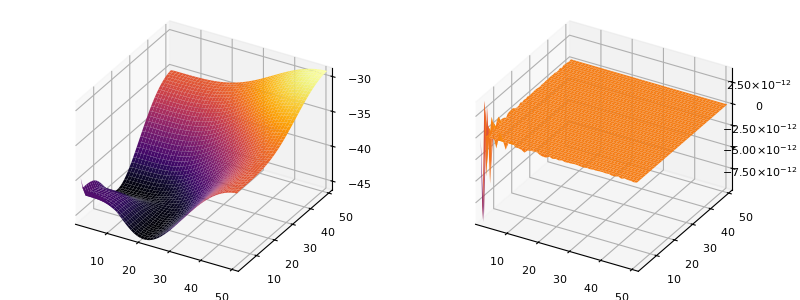

In [12]:
plot(surface(collect(1:length(qi)),collect(1:length(qi)),[real(Vmat[x,y]) for y in 1:length(qi),x in 1:length(qi)],legend=false),
    surface(collect(1:length(qi)),collect(1:length(qi)),[imag(Vmat[x,y]) for y in 1:length(qi),x in 1:length(qi)],legend=false)
    ,layout=(1,2),size=(800,300))

In [13]:
VMat!(mDsc+mDsn-1e-3;isπ=false)

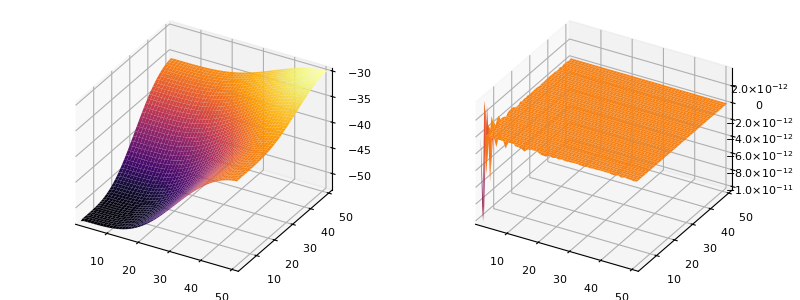

In [14]:
plot(surface(collect(1:length(qi)),collect(1:length(qi)),[real(Vmat[x,y]) for y in 1:length(qi),x in 1:length(qi)],legend=false),
    surface(collect(1:length(qi)),collect(1:length(qi)),[imag(Vmat[x,y]) for y in 1:length(qi),x in 1:length(qi)],legend=false)
    ,layout=(1,2),size=(800,300))

In [12]:
Gc(E,q)=1/(2π^2)/(E-mDsc-mDsn-q^2/(2*μf(mDsn,mDsc)))

Gc (generic function with 1 method)

In [13]:
function GMat!(E;rs=1,Λ=0.5,qi=qi,wi=wi,des=Gmat)
    find_qw(E,Λ;rs=rs)
    μ1=μf(mDsn,mDsc)
    k1=qi[1]
    
    tmp=zero(ComplexF64)
    
    for j in eachindex(wi)
        des[1+j,1+j]=wi[j]*qi[1+j]^2*Gc(E,qi[1+j])
        tmp+=-wi[j]*k1^2*Gc(E,qi[1+j])
    end
    des[1,1]=tmp+μ1*k1/(2π^2)*(log((Λ+k1)/(Λ-k1))-im*π)
    
    return nothing
end

GMat! (generic function with 1 method)

In [14]:
function detVG(E;rs=1,Λ=0.5,Cv = 0.0,Cp=0.0,I=0,J=1,isπ=true)
    VMat!(E;rs=rs,Λ=Λ,Cv = Cv,Cp=Cp,I=I,J=J,isπ=isπ)
    GMat!(E;rs=rs,Λ=Λ)
    return det(LinearAlgebra.I-Vmat*Gmat)
end

detVG (generic function with 1 method)

In [15]:
function TMat!(E;rs=1,Λ=0.5,Cv = 0.0,Cp=0.0,I=0,J=1,isπ=true,des=Tmat)
    VMat!(E;rs=rs,Λ=Λ,Cv = Cv,Cp=Cp,I=I,J=J,isπ=isπ)
    GMat!(E;rs=rs,Λ=Λ)
    des .=inv(LinearAlgebra.I-Vmat*Gmat)*Vmat
    nothing
end

TMat! (generic function with 1 method)

# parameter study

In [16]:
function find_poles(pars;isπ=true)
    _rs,_lam,Cv,Cp,I,J=pars
    function f!(F, x)
        e, γ = x
        tmp = detVG(e + im * γ; Λ = _lam,rs = _rs,Cv = Cv,Cp=Cp,I=I,J=J,isπ=isπ)
        F[1] = real(tmp)
        F[2] = imag(tmp)
    end
    tmp=NLsolve.nlsolve((F, x) -> f!(F, x), [mDsn + mDsc - 1e-3, 0.0])
    return tmp.residual_norm <1e-8 ? (tmp.zero[1]-mDsn-mDsc)+im*tmp.zero[2] : NaN+im*NaN
end

find_poles (generic function with 1 method)

In [17]:
find_poles([1,0.4,0.4,0.0,0,1])

-0.0013363163037740655 - 9.275645870775658e-20im

In [17]:
Λv=collect(0.3:0.05:1.2);

## cv=cp=0.0,I=0,J=1 with pion

In [18]:
poles_rs1=[find_poles([1,λ,0.0,0.0,0,1]) for λ in Λv];
poles_rs2=[find_poles([2,λ,0.0,0.0,0,1]) for λ in Λv];

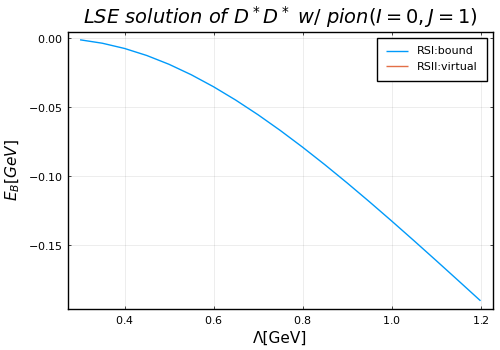

In [23]:
plot(xlabel="Λ[GeV]",ylabel=L"E_B[GeV]",title=L"LSE\ solution\ of\ D^*D^*\ w/\ pion(I=0,J=1)")
plot!(Λv,real.(poles_rs1),label="RSI:bound")
plot!(Λv,real.(poles_rs2),label="RSII:virtual")

## cv=cp=0.0,I=0,J=1 without pion

In [19]:
poles_rs1_nopion=[find_poles([1,λ,0.0,0.0,0,1];isπ=false) for λ in Λv];
poles_rs2_nopion=[find_poles([2,λ,0.0,0.0,0,1];isπ=false) for λ in Λv];

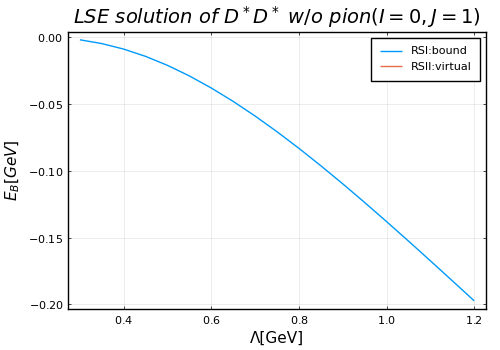

In [34]:
plot(xlabel="Λ[GeV]",ylabel=L"E_B[GeV]",title=L"LSE\ solution\ of\ D^*D^*\ w/o\ pion(I=0,J=1)")
plot!(Λv,real.(poles_rs1_nopion),label="RSI:bound")
plot!(Λv,real.(poles_rs2_nopion),label="RSII:virtual")

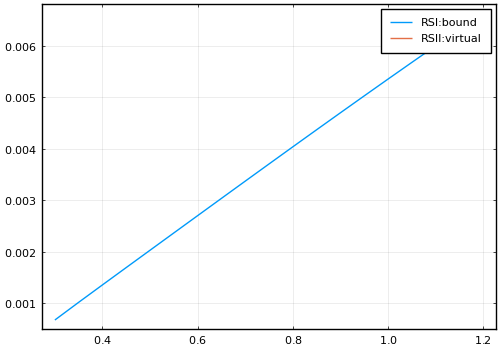

In [27]:
plot(Λv,real.(poles_rs1 .- poles_rs1_nopion),label="RSI:bound")
plot!(Λv,real.(poles_rs2 .- poles_rs2_nopion),label="RSII:virtual")

## cp=0.0,I=0,J=1 with pion

In [34]:
poles_rs1_cv=[find_poles([1,λ,0.5,0.0,0,1]) for λ in Λv];
poles_rs2_cv=[find_poles([2,λ,0.5,0.0,0,1]) for λ in Λv];

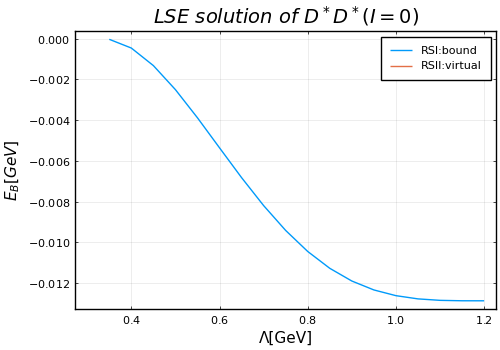

In [35]:
plot(xlabel="Λ[GeV]",ylabel=L"E_B[GeV]",title=L"LSE\ solution\ of\ D^*D^*(I=0)")
plot!(Λv,real.(poles_rs1_cv),label="RSI:bound")
plot!(Λv,real.(poles_rs2_cv),label="RSII:virtual")

## parameters from $T_{cc}^+$

In [35]:
find_poles([1,0.4,0.06044489449156236,0.5310114035552814,0,1])|>println
find_poles([2,0.4,0.06044489449156236,0.5310114035552814,0,1])|>println

-0.006137320290909631 + 6.869289379692283e-19im
NaN + NaN*im


In [36]:
find_poles([1,0.5,0.3959205584234702,0.42559923638052116,0,1])|>println
find_poles([2,0.5,0.3959205584234702,0.42559923638052116,0,1])|>println

-0.004542807239055424 - 4.2798113227039086e-19im
NaN + NaN*im


In [37]:
find_poles([1,0.6,0.5387126543822935,0.05894677461055298,0,1])|>println
find_poles([2,0.6,0.5387126543822935,0.05894677461055298,0,1])|>println

-0.0038946515219877575 - 5.626938331483373e-19im
NaN + NaN*im


In [24]:
df_tcc_cv=DataFrame(CSV.File("./output/df_cv.csv", header = ["Λ", "cv","cp","chi2","δΛ"]))

Row,Λ,cv,cp,chi2,δΛ
,Float64,Float64,Float64,Float64,Float64
1,0.396144,0.0,0.0,14.6907,0.0010708
2,0.406574,0.05,0.0,14.7925,9.35406e-6
3,0.418013,0.1,0.0,14.8565,0.00106976
4,0.427908,0.15,0.0,16.0446,0.00091588
5,0.443976,0.2,0.0,14.967,0.00103724
6,0.458998,0.25,0.0,15.0305,3.87699e-5
7,0.475823,0.3,0.0,15.0499,0.00108523
8,0.491791,0.35,0.0,16.1788,0.00103412
9,0.513466,0.4,0.0,16.2047,0.00128803


In [25]:
poles_rs1=[]

Any[]

In [26]:
for i in 1:16
    println(i)
    push!(poles_rs1,find_poles([1,df_tcc_cv.Λ[i],df_tcc_cv.cv[i],df_tcc_cv.cp[i],0,1]))
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16


In [27]:
gr(frame=:box, minorticks=5, size=(500,350),titlefontsize=11
    ,guidefontsize=12,tickfontsize=11,legendfontsize=9,
    bg_color_legend = RGBA(1,1,1,0.15), markerstrokecolor= :auto);

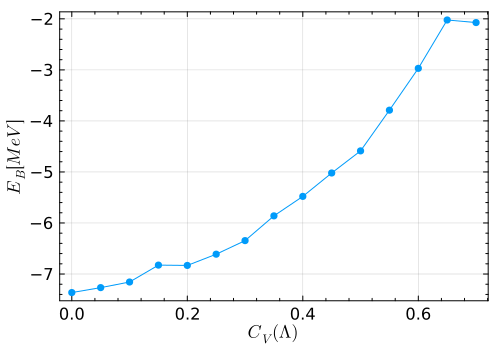

In [28]:
plot(df_tcc_cv.cv[1:15],real.(poles_rs1[1:15] .*1e3),xlabel=L"C_V(\Lambda)",ylabel=L"E_B[MeV]",legend=false,markershape=:circle)
# savefig("./images/poles_dsds.pdf")
current()

In [37]:
poles_rs2=[]

Any[]

In [38]:
for i in 1:16
    println(i)
    push!(poles_rs2,find_poles([2,df_tcc_cv.Λ[i],df_tcc_cv.cv[i],df_tcc_cv.cp[i],0,1]))
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16


In [40]:
poles_rs2

16-element Vector{Any}:
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im
 NaN + NaN*im

# Without crossing terms

In [35]:
function potential_DsDs(E, p, q; I=0, J=0, Cv=0.0, Cp=0.0, isπ=true)
    q01, q02 = q0f(E, mDsc, mDsn, mDsc, mDsn), q0f(E, mDsc, mDsn, mDsn, mDsc)
    res = zero(ComplexF64)

    res += -gs^2 * pwa_central(p, q, mσ^2 - q01^2)
    if isπ == true
        res += -g^2 / fπ^2 / 2 * pwa_tensor_ss(p, q, mπn^2 - q01^2)
        res += -g^2 / fπ^2 / 2 * pwa_tensor_ss(p, q, mπc^2 - q02^2) * (-2) * (I - 1 / 2) * 2
    end
    res += -g^2 / fπ^2 / 2 * pwa_tensor_ss(p, q, mη^2 - q01^2; a=Cp) * (-1 / 3)
    res += -β^2 * gV^2 * (1 - q01^2 / mρn^2) / sqrt(16) * pwa_central(p, q, mρn^2 - q01^2) 
#     res+= 2 * gλ^2 * gV^2 * pwa_VVV_ss(p, q, mρn^2 - q01^2; a=Cv, J=J)
    res += -β^2 * gV^2 * (1 - q01^2 / mω^2) / sqrt(16) * pwa_central(p, q, mω^2 - q01^2)* (-1) 
#     res+= 2 * gλ^2 * gV^2 * pwa_VVV_ss(p, q, mω^2 - q01^2; a=Cv, J=J) * (-1)
    res += -β^2 * gV^2 * (1 - q01^2 / mJψ^2) / sqrt(16) * pwa_central(p, q, mJψ^2 - q01^2) * (-2)
    # res += -g^2 / fπ^2 / 2 * pwa_tensor_ss(p, q, mηc^2 - q01^2) * (-2)

    res += -β^2 * gV^2 * (1 - q02^2 / mρc^2) / sqrt(16) * pwa_central(p, q, mρc^2 - q02^2)* (-2) * (I - 1 / 2) * 2 
#     res+= 2 * gλ^2 * gV^2 * pwa_VVV_ss(p, q, mρc^2 - q01^2; a=Cv, J=J) * (-2) * (I - 1 / 2) * 2
    return res
end

potential_DsDs (generic function with 1 method)

In [28]:
poles_rs1_J1_nc=[find_poles([1,λ,0.0,0.0,0,1]) for λ in Λv];
poles_rs2_J1_nc=[find_poles([2,λ,0.0,0.0,0,1]) for λ in Λv];

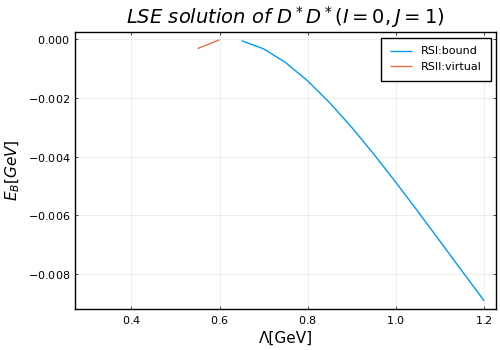

In [38]:
plot(xlabel="Λ[GeV]",ylabel=L"E_B[GeV]",title=L"LSE\ solution\ of\ D^*D^*(I=0,J=1)")
plot!(Λv,real.(poles_rs1_J1_nc),label="RSI:bound")
plot!(Λv,real.(poles_rs2_J1_nc),label="RSII:virtual")

In [34]:
find_poles([1,0.4,0.06044489449156236,0.5310114035552814,0,1])|>println
find_poles([2,0.4,0.06044489449156236,0.5310114035552814,0,1])|>println

-0.006160458268369862 - 9.798465105137024e-19im
NaN + NaN*im


In [36]:
find_poles([1,0.5,0.3959205584234702,0.42559923638052116,0,1])|>println
find_poles([2,0.5,0.3959205584234702,0.42559923638052116,0,1])|>println

NaN + NaN*im
NaN + NaN*im


In [37]:
find_poles([1,0.6,0.5387126543822935,0.05894677461055298,0,1])|>println
find_poles([2,0.6,0.5387126543822935,0.05894677461055298,0,1])|>println

NaN + NaN*im
-3.078147697843647e-5 - 2.1558259161924298e-19im


# For manuscript after review

In [20]:
df_pre_paras1=DataFrame(CSV.File("./output/review_lamv_Cv_scheme1.csv"));
pre_Cv1=df_pre_paras1.Cv;
pre_Λv1=df_pre_paras1.lam;

In [21]:
df_pre_paras2=DataFrame(CSV.File("./output/review_lamv_Cv_schemeII.csv"));
pre_Cv2=df_pre_paras2.Cv;
pre_Λv2=df_pre_paras2.lam;

In [22]:
df_pre_paras3=DataFrame(CSV.File("./output/review_lamv_Cv_scheme3.csv"));
pre_Cv3=df_pre_paras3.Cv;
pre_Λv3=df_pre_paras3.lam;

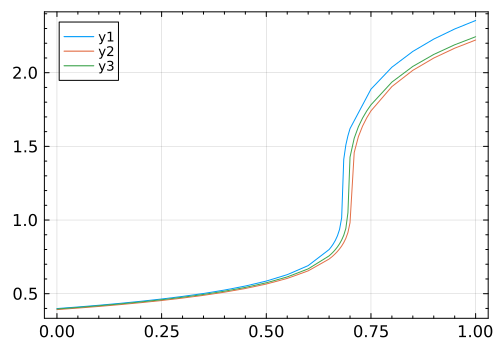

In [23]:
plot(pre_Cv1,pre_Λv1)
plot!(pre_Cv2,pre_Λv2)
plot!(pre_Cv3,pre_Λv3)

In [24]:
poles_rs1_review1=[]

Any[]

In [25]:
for i in 1:30
    println(i)
    push!(poles_rs1_review1,find_poles([1,pre_Λv1[i],pre_Cv1[i],0.0,0,1];isπ=false))
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30


In [26]:
poles_rs1_review2=[]

Any[]

In [27]:
for i in 1:35
    println(i)
    push!(poles_rs1_review2,find_poles([1,pre_Λv2[i],pre_Cv2[i],0.0,0,1];isπ=false))
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35


In [28]:
poles_rs1_review3=[]

Any[]

In [29]:
for i in 1:35
    println(i)
    push!(poles_rs1_review3,find_poles([1,pre_Λv3[i],pre_Cv3[i],0.0,0,1];isπ=true))
end

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35


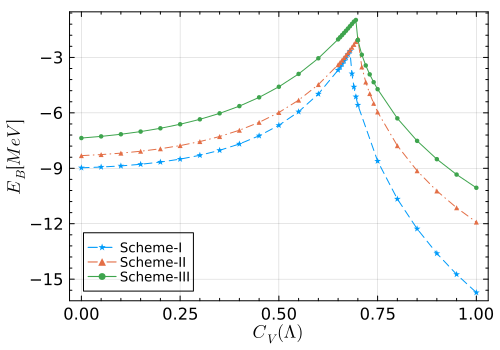

In [31]:
plot(pre_Cv1,real.(poles_rs1_review1 .*1e3),xlabel=L"C_V(\Lambda)",ylabel=L"E_B[MeV]",label="Scheme-I",ls=:dash,markersize=3.5,marker=:star5,legend=:bottomleft)
plot!(pre_Cv2,real.(poles_rs1_review2 .*1e3),label="Scheme-II",markersize=2.5,marker=:utriangle,ls=:dashdot)
plot!(pre_Cv3,real.(poles_rs1_review3 .*1e3),label="Scheme-III",markersize=2.5,marker=:circle)
savefig("./images/poles_dsds_review.pdf")
current()